<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/golf/05_logit_discrepancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf putting 5 — Binomial with logit-scale discrepancy

Return to an exact Binomial likelihood. Add one local error per distance bin on the logit scale, with a shared scale controlling how large those departures can be.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1" \
    "jinja2>=3.1.5"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

DATA_BASE = "https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/golf/data"
golf = pd.read_csv(f"{DATA_BASE}/broadie_2018_putting.csv")
golf["rate"] = golf["made"] / golf["attempts"]

BALL_RADIUS_FT = (1.68 / 2) / 12
CUP_RADIUS_FT = (4.25 / 2) / 12

golf

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


,distance_ft,attempts,made,rate
0,0.28,45198,45183,0.999668
1,0.97,183020,182899,0.999339
2,1.93,169503,168594,0.994637
3,2.92,113094,108953,0.963384
4,3.93,73855,64740,0.876582
5,4.94,53659,41106,0.766060
6,5.94,42991,28205,0.656068
7,6.95,37050,21334,0.575816
8,7.95,33275,16615,0.499324
9,8.95,30836,13503,0.437897


In [3]:
DRAW_COLOR = "#12505e"  # darker shade of the band colour C0

def plot_curve_draws(ax, x, curves):
    """Thin lines for individual draws of the success-probability curve."""
    ax.plot(x, curves, color=DRAW_COLOR, lw=0.8, alpha=0.55, zorder=1.5)

def plot_simulated_datasets(ax, x, datasets):
    """Dots for simulated rates, nudged sideways so nearby values stay visible."""
    jitter = np.random.default_rng(RANDOM_SEED).uniform(-0.15, 0.15, datasets.shape)
    ax.set_autoscalex_on(False)  # keep the same distance axis as the other plots
    ax.scatter(
        np.asarray(x)[:, None] + jitter,
        datasets,
        s=14,
        color=DRAW_COLOR,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.4,
        zorder=1.5,
    )

def add_interval_legend(ax, line_label="mean", draws_label="20 draws", draws_as_points=False):
    """Compact one-row legend above the plot, so it never hides draws or data."""
    if draws_as_points:
        draws_handle = Line2D(
            [0], [0], marker="o", linestyle="none", color=DRAW_COLOR,
            markersize=4, label=draws_label,
        )
    else:
        draws_handle = Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label)
    ax.legend(
        handles=[
            Line2D([0], [0], color="C1", lw=1.6, label=line_label),
            Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
            Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
            draws_handle,
            Line2D(
                [0], [0], marker="o", linestyle="none", color="black",
                markersize=4.5, label="observed",
            ),
        ],
        loc="lower left",
        bbox_to_anchor=(0, 1.01),
        ncols=5,
        fontsize=8,
        handlelength=1.4,
        handletextpad=0.45,
        columnspacing=0.9,
        borderaxespad=0,
        frameon=False,
    )

def plot_residuals(idata, data, var_name="p_base", title="Residuals"):
    """Plot observed minus posterior-median mechanistic probability."""
    fitted = idata["posterior"][var_name].median(dim=("chain", "draw")).to_numpy()
    x = data["distance_ft"].to_numpy()
    residual = data["rate"].to_numpy() - fitted
    order = np.argsort(x)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.plot(x[order], residual[order], marker="o")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Observed − fitted probability",
        title=title,
    )
    return ax

## Model

$$
\operatorname{logit}(p_j)=\operatorname{logit}(p_{base,j})+\sigma_{logit}\eta_j,
\qquad \eta_j\sim N(0,1).
$$

This keeps $p_j$ inside $[0,1]$ while allowing each bin to depart from the mechanistic curve.

In [4]:
coords = {"obs_id": golf["distance_ft"].to_numpy()}

with pm.Model(coords=coords) as model:
    distance = pm.Data("distance", golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_distance = pm.LogNormal("sigma_distance", mu=np.log(0.10), sigma=0.7)
    distance_tolerance = 3.0
    overshot = 1.0

    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_angle = pm.Deterministic(
        "p_angle",
        2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1,
        dims="obs_id",
    )
    p_distance = pm.Deterministic(
        "p_distance",
        pm.math.invprobit(
            (distance_tolerance - overshot) / ((distance + overshot) * sigma_distance)
        )
        - pm.math.invprobit(
            -overshot / ((distance + overshot) * sigma_distance)
        ),
        dims="obs_id",
    )
    p_base = pm.Deterministic("p_base", p_angle * p_distance, dims="obs_id")
    sigma_logit = pm.HalfNormal("sigma_logit", sigma=1)
    eta = pm.Normal("eta", mu=0, sigma=1, dims="obs_id")
    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(pm.math.logit(pm.math.clip(p_base, 1e-9, 1 - 1e-9)) + sigma_logit * eta),
        dims="obs_id",
    )

    made = pm.Binomial(
        "made",
        n=attempts,
        p=p,
        observed=golf["made"].to_numpy(),
        dims="obs_id",
    )

## Prior predictive check

Before fitting, ask what success rates the prior says are plausible across putting distance. The observed rates are shown only as a reference; they do not condition the prior. The dots are 20 simulated datasets, nudged sideways so nearby values stay visible.

In [5]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["made"],
        random_seed=RANDOM_SEED,
    )

Sampling: [eta, made, sigma_angle_deg, sigma_distance, sigma_logit]


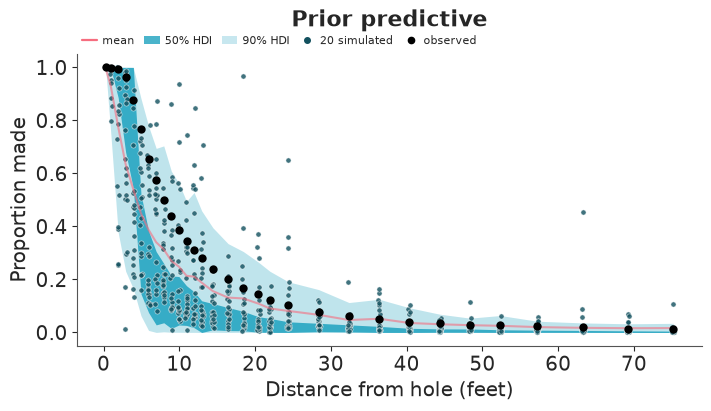

In [6]:
# Plot on the rate scale: made / attempts at each distance.
prior["observed_data"]["rate"] = prior["observed_data"]["made"] / prior["constant_data"]["attempts"]
prior["prior_predictive"]["rate"] = (
    prior["prior_predictive"]["made"] / prior["constant_data"]["attempts"]
)
prior_datasets = azb.extract(
    prior,
    group="prior_predictive",
    var_names="rate",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    prior,
    x="distance",
    y="rate",
    y_obs="rate",
    group="prior_predictive",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_simulated_datasets(ax, golf["distance_ft"], prior_datasets)
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made", ylim=(-0.05, 1.05))
ax.set_title("Prior predictive", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean", draws_label="20 simulated", draws_as_points=True)
plt.show()

## Fit and diagnose

Do not interpret the scientific fit until the sampler diagnostics are acceptable.

In [7]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.97,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=['sigma_angle_deg', 'sigma_distance', 'sigma_logit'],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

local_rhat = idata["posterior"]["eta"].azstats.rhat()
local_ess = idata["posterior"]["eta"].azstats.ess(method="bulk")
print(f"Worst eta R-hat: {float(local_rhat.max()):.3f}")
print(f"Smallest eta bulk ESS: {float(local_ess.min()):.0f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [sigma_angle_deg, sigma_distance, sigma_logit, eta]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 58 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Divergences: 0
Worst eta R-hat: 1.012
Smallest eta bulk ESS: 381


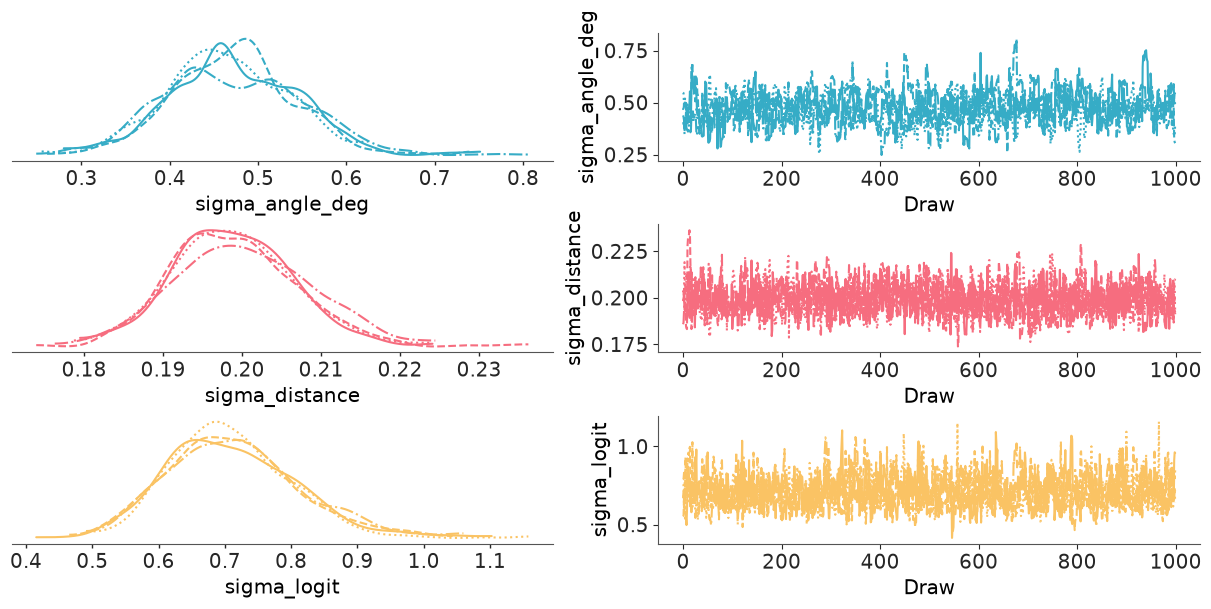

In [8]:
azp.plot_trace_dist(idata, var_names=['sigma_angle_deg', 'sigma_distance', 'sigma_logit']);

## Posterior fit

This plot shows posterior uncertainty in the continuous underlying mechanism $p_{base}(x)$ **before** the local discrepancy terms are applied. That distinction matters: the full model can fit the data by using local corrections even when the shared mechanism still has systematic structure. The thin lines are 20 posterior draws of that curve.

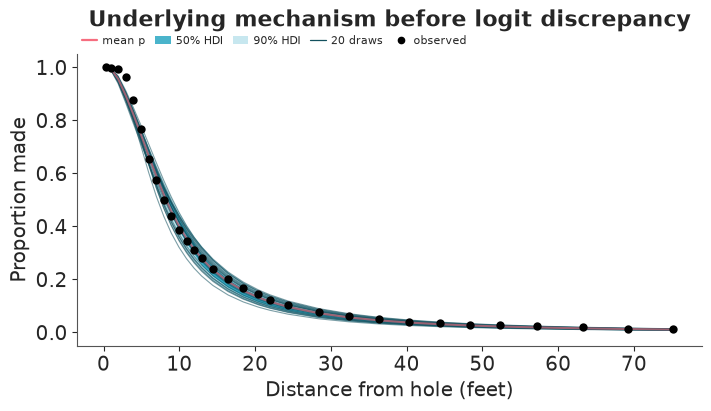

In [9]:
idata["observed_data"]["rate"] = idata["observed_data"]["made"] / idata["constant_data"]["attempts"]
posterior_curves = azb.extract(
    idata,
    group="posterior",
    var_names="p_base",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    idata,
    x="distance",
    y="p_base",
    y_obs="rate",
    group="posterior",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_curve_draws(ax, golf["distance_ft"], posterior_curves)
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made", ylim=(-0.05, 1.05))
ax.set_title("Underlying mechanism before logit discrepancy", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean p", draws_label="20 draws")
plt.show()

## Posterior predictive check

Now generate new outcomes at the same putting distances from the **full fitted model**, including its local discrepancy terms. This uses the same graphical grammar as the prior predictive check; the difference is conditioning on the observed data. Each of the 20 simulated datasets comes from the same posterior draw as one of the 20 curves above.

In [10]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["made"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Sampling: [made]


Output()

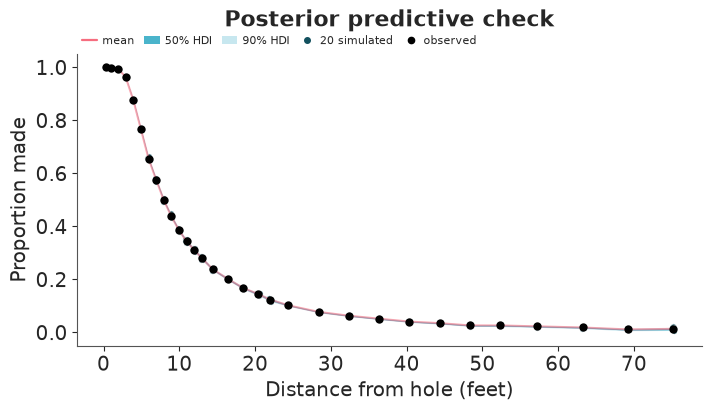

In [11]:
# sample_posterior_predictive replaced observed_data, so add the observed rate again.
idata["observed_data"]["rate"] = idata["observed_data"]["made"] / idata["constant_data"]["attempts"]
idata["posterior_predictive"]["rate"] = (
    idata["posterior_predictive"]["made"] / idata["constant_data"]["attempts"]
)
# Same seed and number of draws as the curves above: dataset i uses the same posterior draw as curve i.
posterior_datasets = azb.extract(
    idata,
    group="posterior_predictive",
    var_names="rate",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    idata,
    x="distance",
    y="rate",
    y_obs="rate",
    group="posterior_predictive",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_simulated_datasets(ax, golf["distance_ft"], posterior_datasets)
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made", ylim=(-0.05, 1.05))
ax.set_title("Posterior predictive check", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean", draws_label="20 simulated", draws_as_points=True)
plt.show()

## Model criticism

These residuals deliberately compare the observations with $p_{base}(x)$, before the bin-specific discrepancy terms. They ask whether the shared mechanism still misses a systematic feature that the local corrections are masking.

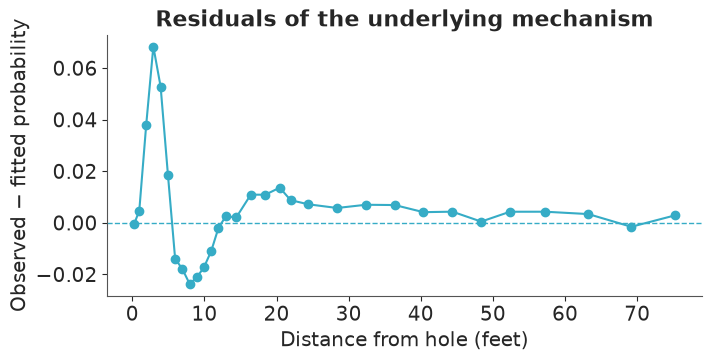

In [12]:
plot_residuals(idata, golf, var_name="p_base", title="Residuals of the underlying mechanism");